In [1]:
import requests
import pandas as pd
import numpy as np
import random
import json

from langchain_openai import ChatOpenAI
from langchain_community.embeddings import XinferenceEmbeddings
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas import EvaluationDataset, SingleTurnSample
from ragas import evaluate, metrics
from ragas.run_config import RunConfig
from pydantic import SecretStr
from tqdm import tqdm
from loguru import logger

In [83]:
# 读取 JSONL 文件
logger.info('Loading JSONL file...')
df = pd.read_json("./outputs/qac_dataset.jsonl", lines=True, encoding="utf-8")
logger.success("JSONL file is read.")

# 创建 List 存储 QAC 数据
logger.info('Creating QAC list...')
qac_list = []
for index, row in df.iterrows():
    qac_list.append({
        "question": row["question"],
        "answer": row["answer"],
        "context": row["context"]
    })
logger.success(f"QAC list is created. Total QAC size: {len(qac_list)}")


# 随机挑选出 200 个 QAC 作为测试集
random_samples = random.sample(
    qac_list, min(200, len(qac_list)),
)

# 将随机挑选出的 200 个 QAC 保存为 JSONL 文件
logger.info('Creating Test QAC list...')
with open("qac_dataset_test.jsonl", "w", encoding="utf-8") as f:
    for qac in random_samples:
        f.write(json.dumps(qac, ensure_ascii=False) + "\n")
logger.success(f"Test QAC list is created. Total Test QAC size: {len(random_samples)}")

2025-06-21 21:09:22.207 | INFO     | __main__:<module>:2 - Loading JSONL file...
2025-06-21 21:09:22.261 | SUCCESS  | __main__:<module>:4 - JSONL file is read.
2025-06-21 21:09:22.262 | INFO     | __main__:<module>:7 - Creating QAC list...
2025-06-21 21:09:22.306 | SUCCESS  | __main__:<module>:15 - QAC list is created. Total QAC size: 1403


In [14]:
from pathlib import Path
from datetime import datetime

import hashlib

# 构建 Dify API 请求头
logger.info('Building Dify API request header...')

rag_base_url = "http://10.26.58.108/v1/chat-messages"
rag_api_key = "app-yWQGLNnaQjOR2vVSxhDnoND5"

rag_headers = {
    'content-type': 'application/json; charset=UTF-8',
    'Authorization': f'Bearer {rag_api_key}',
}
logger.success("Dify API request header is built.")

# 读取 Subset 数据集
logger.info('Loading TEST JSONL file...')
df = pd.read_json("qac_dataset_test.jsonl", lines=True, encoding="utf-8")
logger.success("TEST JSONL file is read.")

# 创建 List 存储 QAC 数据
logger.info('Creating QAC list...')
qac_list = []
for index, row in df.iterrows():
    qac_list.append({
        "question": row["question"],
        "answer": row["answer"],
        "context": row["context"]
    })
logger.success(f"QAC list is created. Total QAC size: {len(qac_list)}")

# 提交 QAC 数据集
logger.info('Submitting QAC items to Dify...')
samples = []
for qac in tqdm(
    qac_list, desc="Submitting QAC items to Dify",
    unit="item", total=len(qac_list)
):  
    # 拿到 QAC 数据
    question = qac.get("question", "")
    reference = qac.get("answer", "")
    reference_contexts = [qac.get("context", "")]
    
    # 构建 QAC API 请求参数
    rag_payload = {
        "inputs": {},
        "query": question,
        "response_mode": "blocking",
        "conversation_id": "",
        "user": "abc-123",
        "files": []
    }

    # 提取 metadata 里面 retriever_resources 中的 content 作为召回文本块
    response = requests.post(
        url=rag_base_url,
        headers=rag_headers,
        json=rag_payload,
    )

    res = response.json()
    
    # 每经过一次循环就保存成本地文件，在 logs 文件夹中
    try:
        LOG_DIR = Path("logs")
        LOG_DIR.mkdir(exist_ok=True)

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
        content_hash = hashlib.md5(json.dumps(res).encode()).hexdigest()[:6]
        filename = f"{timestamp}_{content_hash}.json"
        log_path = LOG_DIR / filename
        with open(log_path, 'w', encoding='utf-8') as f:
            json.dump({
                "metadata": {
                    "save_time": datetime.now().isoformat(),
                    "source": "api_response"
                },
                "data": res
            }, f, indent=2, ensure_ascii=False)
    except Exception as e:
        print(f"❌ 保存失败: {e}")
        raise

    retriever_resources = res.get('metadata', {}).get('retriever_resources', [])
    retriever_context = [
        doc.get("content", "") for doc in retriever_resources
    ]
    response = res.get('answer', "")
    
    # 创建 SingleTurnSample 对象
    # user_input: 用户输入的问题
    # retrieved_contexts: AI 召回的相关文本
    # response: AI 生成的回答
    # reference_contexts: 人给出的正确召回片段
    # reference: 人给出的正确回答
    sample = SingleTurnSample(
        user_input=question,
        retrieved_contexts=retriever_context,  
        response=response,
        reference_contexts=reference_contexts,  
        reference=reference  
    )

    # 将样本添加到列表
    samples.append(sample)
    
logger.success('Submitted QAC items to Dify.')

2025-06-23 20:37:15.292 | INFO     | __main__:<module>:7 - Building Dify API request header...
2025-06-23 20:37:15.294 | SUCCESS  | __main__:<module>:16 - Dify API request header is built.
2025-06-23 20:37:15.295 | INFO     | __main__:<module>:19 - Loading TEST JSONL file...
2025-06-23 20:37:15.308 | SUCCESS  | __main__:<module>:21 - TEST JSONL file is read.
2025-06-23 20:37:15.309 | INFO     | __main__:<module>:24 - Creating QAC list...
2025-06-23 20:37:15.316 | SUCCESS  | __main__:<module>:32 - QAC list is created. Total QAC size: 200
2025-06-23 20:37:15.316 | INFO     | __main__:<module>:35 - Submitting QAC items to Dify...
Submitting QAC items to Dify: 100%|██████████| 200/200 [2:07:58<00:00, 38.39s/item]  
2025-06-23 22:45:13.534 | SUCCESS  | __main__:<module>:109 - Submitted QAC items to Dify.


In [15]:
try:
    logger.info("Creating the LLM and Embeddings.")
    # 创建 LLM 和 Embeddings 模型
    evaluator_llm = LangchainLLMWrapper(
        ChatOpenAI(
            model="deepseek-chat",
            api_key=SecretStr("sk-574d077e01be45beab39804304a15109"),
            base_url="https://api.deepseek.com/v1",
            temperature=0,
            max_tokens=None,
            timeout=None,
            max_retries=2,
        )
    )
    logger.success(f"LLM successfully created.")
    # 用于评估的嵌入模型
    evaluator_embeddings = LangchainEmbeddingsWrapper(
        XinferenceEmbeddings(
            server_url="http://10.26.58.108:9998",
            model_uid="bge-m3"
        )
    )
    logger.success(f"Embeddings successfully created.")
except Exception as e:
    logger.exception(f"Failed to initialize LLM or Embeddings: {e}")
    raise

2025-06-23 22:45:19.247 | INFO     | __main__:<module>:2 - Creating the LLM and Embeddings.
2025-06-23 22:45:19.275 | SUCCESS  | __main__:<module>:15 - LLM successfully created.
2025-06-23 22:45:19.286 | SUCCESS  | __main__:<module>:23 - Embeddings successfully created.


In [16]:
# 将最后的结果添加到 EvaluationDataset 中
eval_dataset = EvaluationDataset(samples=samples)

# 评估指标列表
metrics_list = [
    # 答案正确性，通过嵌入模型比较答案的相似程度
    metrics.answer_correctness,
    # 答案相关性，越是不完整或包含冗余信息的答案，得分越低
    metrics.answer_relevancy,
    # 忠实度/可信度，衡量了生成的答案与给定上下文的事实一致性
    metrics.faithfulness,
    # 上下文精度，评估所有在上下文中呈现的与基本事实相关的条目是否排名较高。
    metrics.context_precision,
    # 上下文召回率，衡量检索到的上下文与人类提供的真实答案的一致程度。
    metrics.context_recall,
]

# 创建 run config
eval_run_config = RunConfig(timeout=600, log_tenacity=True)

# 评估数据集
logger.info('Evaluating QAC items...')
results = evaluate(
    dataset=eval_dataset,
    metrics=metrics_list,
    llm=evaluator_llm,
    embeddings=evaluator_embeddings,
    run_config=eval_run_config
)
logger.success('Evaluated QAC items.')

# 保存结果到 CSV 文件
logger.info('Saving results to CSV file...')
results.to_pandas().to_csv("qac_results.csv")
logger.success('Results saved to CSV file.')

2025-06-23 22:45:21.869 | INFO     | __main__:<module>:22 - Evaluating QAC items...


Evaluating:   0%|          | 0/1000 [00:00<?, ?it/s]

2025-06-23 23:14:44.525 | SUCCESS  | __main__:<module>:30 - Evaluated QAC items.
2025-06-23 23:14:44.526 | INFO     | __main__:<module>:33 - Saving results to CSV file...
2025-06-23 23:14:44.550 | SUCCESS  | __main__:<module>:35 - Results saved to CSV file.


In [27]:
# 汇总 Result 中的 Eval 数据
qac_results = {
    "llm": pd.read_csv("./results/qac_results_llm.csv", encoding="utf-8"),
    "128": pd.read_csv("./results/qac_results_128.csv", encoding="utf-8"),
    "256": pd.read_csv("./results/qac_results_256.csv", encoding="utf-8"),
    "512": pd.read_csv("./results/qac_results_512.csv", encoding="utf-8"),
    "1024": pd.read_csv("./results/qac_results_1024.csv", encoding="utf-8"),
    "2048": pd.read_csv("./results/qac_results_2048.csv", encoding="utf-8"),
}

eval_data_dict = {
    "128": {
        "answer_correctness": np.nanmean(
            qac_results["128"]["answer_correctness"].tolist()
        ),
        "answer_relevancy": np.nanmean(
            qac_results["128"]["answer_relevancy"].tolist()
        ),
        "faithfulness": np.nanmean(
            qac_results["128"]["faithfulness"].tolist()
        ),
        "context_precision": np.nanmean(
             qac_results["128"]["context_precision"].tolist()
        ),
        "context_recall": np.nanmean(
            qac_results["128"]["context_recall"].tolist()
        ),
    },
    "256": {
        "answer_correctness": np.nanmean(
            qac_results["256"]["answer_correctness"].tolist()
        ),
        "answer_relevancy": np.nanmean(
            qac_results["256"]["answer_relevancy"].tolist()
        ),
        "faithfulness": np.nanmean(
            qac_results["256"]["faithfulness"].tolist()
        ),
        "context_precision": np.nanmean(
             qac_results["256"]["context_precision"].tolist()
        ),
        "context_recall": np.nanmean(
            qac_results["256"]["context_recall"].tolist()
        ),
    },
    "512": {
        "answer_correctness": np.nanmean(
            qac_results["512"]["answer_correctness"].tolist()
        ),
        "answer_relevancy": np.nanmean(
            qac_results["512"]["answer_relevancy"].tolist()
        ),
        "faithfulness": np.nanmean(
            qac_results["512"]["faithfulness"].tolist()
        ),
        "context_precision": np.nanmean(
             qac_results["512"]["context_precision"].tolist()
        ),
        "context_recall": np.nanmean(
            qac_results["512"]["context_recall"].tolist()
        ),
    },
    "1024": {
        "answer_correctness": np.nanmean(
            qac_results["1024"]["answer_correctness"].tolist()
        ),
        "answer_relevancy": np.nanmean(
            qac_results["1024"]["answer_relevancy"].tolist()
        ),
        "faithfulness": np.nanmean(
            qac_results["1024"]["faithfulness"].tolist()
        ),
        "context_precision": np.nanmean(
             qac_results["1024"]["context_precision"].tolist()
        ),
        "context_recall": np.nanmean(
            qac_results["1024"]["context_recall"].tolist()
        ),
    },
    "2048": {
        "answer_correctness": np.nanmean(
            qac_results["2048"]["answer_correctness"].tolist()
        ),
        "answer_relevancy": np.nanmean(
            qac_results["2048"]["answer_relevancy"].tolist()
        ),
        "faithfulness": np.nanmean(
            qac_results["2048"]["faithfulness"].tolist()
        ),
        "context_precision": np.nanmean(
             qac_results["2048"]["context_precision"].tolist()
        ),
        "context_recall": np.nanmean(
            qac_results["2048"]["context_recall"].tolist()
        ),
    }
}

   Chunk Size              Metric     Score
0         128  Answer Correctness  0.422798
1         128    Answer Relevancy  0.453960
2         128        Faithfulness  0.739161
3         128   Context Precision  0.397917
4         128      Context Recall  0.205833
5         256  Answer Correctness  0.441377
6         256    Answer Relevancy  0.636102
7         256        Faithfulness  0.757277
8         256   Context Precision  0.527500
9         256      Context Recall  0.382667
10        512  Answer Correctness  0.470491
11        512    Answer Relevancy  0.727101
12        512        Faithfulness  0.806458
13        512   Context Precision  0.624583
14        512      Context Recall  0.553250
15       1024  Answer Correctness  0.464926
16       1024    Answer Relevancy  0.760267
17       1024        Faithfulness  0.831783
18       1024   Context Precision  0.696250
19       1024      Context Recall  0.671500
20       2048  Answer Correctness  0.466263
21       2048    Answer Relevanc

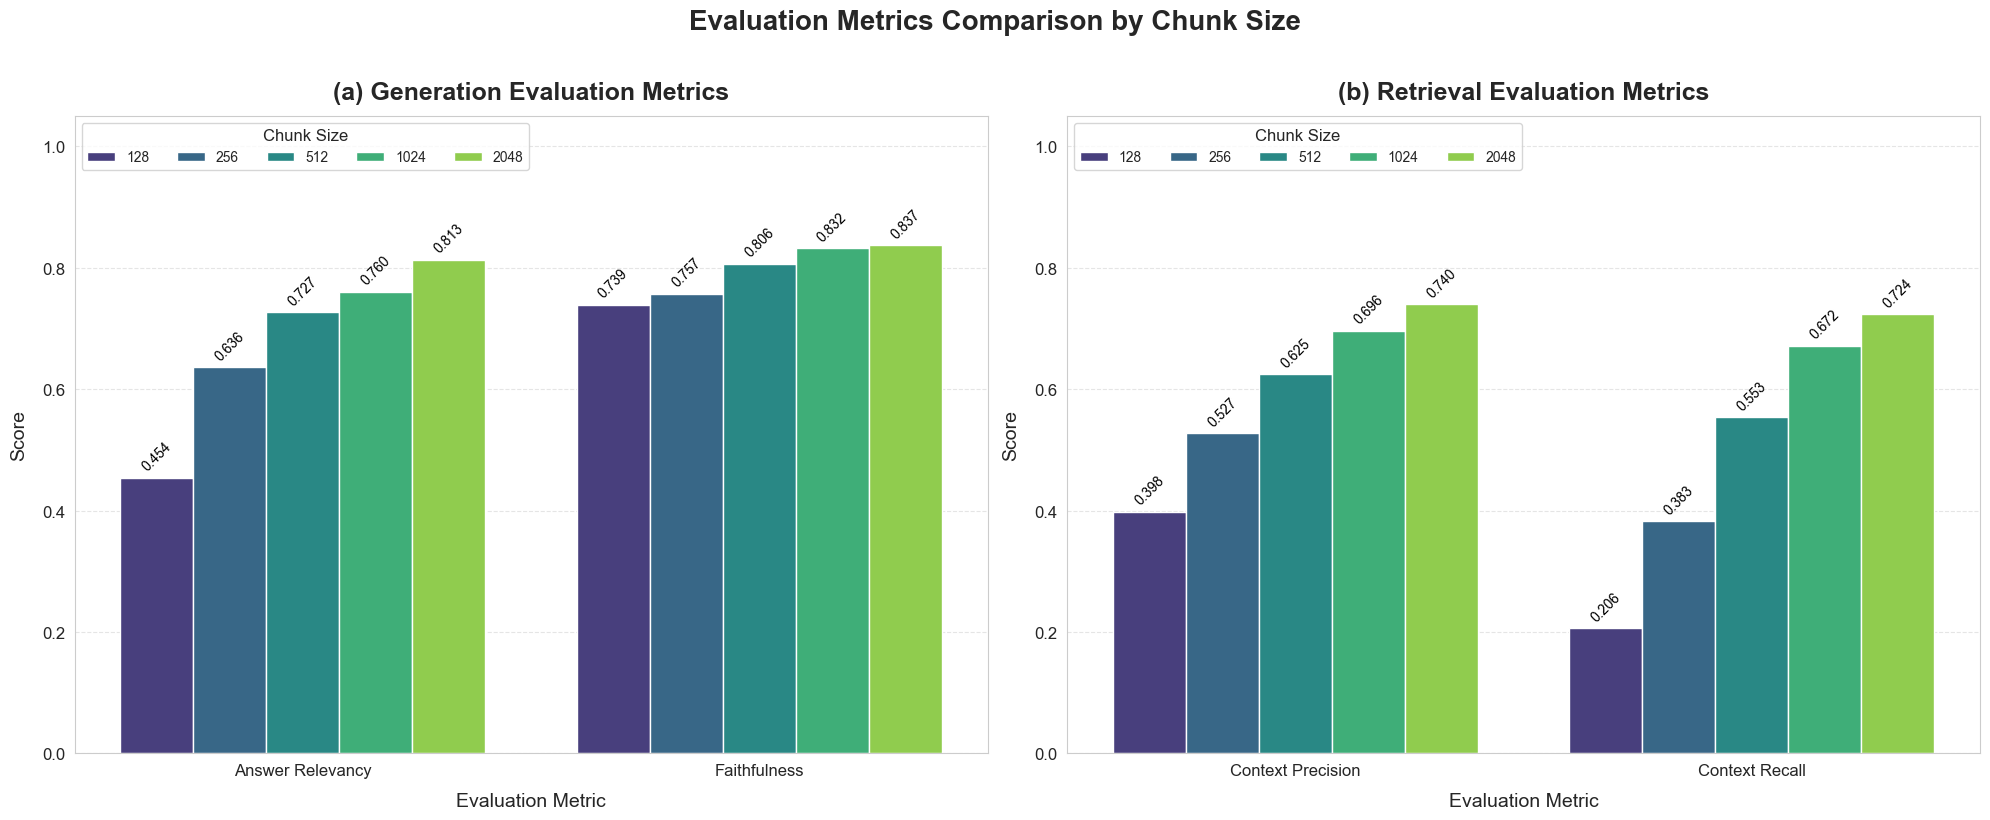

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# 提取数据
chunk_sizes = ['128', '256', '512', '1024', '2048']
metrics = list(eval_data_dict['128'].keys())

# 为每个指标创建数据数组
data_list = []
for chunk_size in eval_data_dict:
    for metric, score in eval_data_dict[chunk_size].items():
        data_list.append({
            'Chunk Size': chunk_size,
            'Metric': metric.replace('_', ' ').title(),
            'Score': score
        })

# 创建DataFrame
df = pd.DataFrame(data_list)

print(df)

# Split metrics into two groups
group_a_metrics = ['Answer Relevancy', 'Faithfulness']
group_b_metrics = ['Context Precision', 'Context Recall']

# 创建图表
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot A - Group A metrics with 'llm' included
df_a = df[df['Metric'].isin(group_a_metrics)]
sns.barplot(
    x="Metric",
    y="Score",
    hue="Chunk Size",
    data=df_a,
    palette="viridis",
    order=group_a_metrics,
    saturation=0.85,
    ax=ax1
)

# Plot B - Group B metrics without 'llm'
df_b = df[(df['Metric'].isin(group_b_metrics)) & (df['Chunk Size'] != 'llm')]
sns.barplot(
    x="Metric",
    y="Score",
    hue="Chunk Size",
    data=df_b,
    palette="viridis",
    order=group_b_metrics,
    saturation=0.85,
    ax=ax2
)

# Add labels and titles for both subplots
for ax, group_name in zip([ax1, ax2], ['(a) Generation', '(b) Retrieval']):
    # Add value labels
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.3f',
            padding=3,
            fontsize=10,
            color='black',
            label_type='edge',
            rotation=45
        )

    # Set subplot titles and labels
    ax.set_title(
        f'{group_name} Evaluation Metrics',
        fontsize=18,
        pad=12,
        fontweight='bold'
    )
    ax.set_xlabel('Evaluation Metric', fontsize=14, labelpad=10)
    ax.set_ylabel('Score', fontsize=14, labelpad=10)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.tick_params(axis='both', which='major', labelsize=12)

    # Adjust legend
    ax.legend(
        title='Chunk Size',
        loc='upper left',
        ncol=6,
        frameon=True,
        fancybox=True,
        framealpha=0.8,
        fontsize=10,
        title_fontsize=12
    )

# Main title for the entire figure
fig.suptitle(
    'Evaluation Metrics Comparison by Chunk Size',
    fontsize=20,
    y=1.02,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# Save as PDF
fig.savefig("evaluation_metrics.pdf", bbox_inches='tight', dpi=300)